# Import

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load data
customers = pd.read_csv("../data_set/customers.csv")
products = pd.read_csv("../data_set/products.csv")
promotions = pd.read_csv("../data_set/promotions.csv")
geography = pd.read_csv("../data_set/geography.csv")
orders = pd.read_csv("../data_set/orders.csv")
order_items = pd.read_csv("../data_set/order_items.csv")
payments = pd.read_csv("../data_set/payments.csv")
returns = pd.read_csv("../data_set/returns.csv")
reviews = pd.read_csv("../data_set/reviews.csv")
shipments = pd.read_csv("../data_set/shipments.csv")
inventory = pd.read_csv("../data_set/inventory.csv")
web = pd.read_csv("../data_set/web_traffic.csv")
sales = pd.read_csv("../data_set/sales.csv")

C:\Users\NganNguyen's laptop\AppData\Local\Temp\ipykernel_7700\2760871804.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data_set/order_items.csv")


# Chuyển sang định dạng time đúng

In [15]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
sales['Date'] = pd.to_datetime(sales['Date'])

# Merge

# Doanh thu theo từng vùng

In [16]:
## Tạo cột line_revenue và gom nhóm theo order_id

# Tạo doanh thu từng dòng
order_items['line_revenue'] = order_items['quantity'] * order_items['unit_price']

# Tính tổng doanh thu mỗi đơn hàng
order_revenue = order_items.groupby('order_id')['line_revenue'].sum().reset_index()

In [19]:
## Ghép bảng orders với geography để lấy vùng (region)
order_region_map = orders.merge(geography[['zip', 'region']], on='zip', how='left')

In [20]:
## Ghép với order_revenue
final_geo_rev = order_region_map.merge(order_revenue, on='order_id')

In [21]:
# Tạo các cột thời gian
final_geo_rev['year'] = final_geo_rev['order_date'].dt.year
final_geo_rev['month'] = final_geo_rev['order_date'].dt.month
final_geo_rev['quarter'] = final_geo_rev['order_date'].dt.quarter
final_geo_rev['year_month'] = final_geo_rev['year'].astype(str) + '-' + final_geo_rev['month'].astype(str).str.zfill(2)
final_geo_rev['year_quarter'] = final_geo_rev['year'].astype(str) + '-Q' + final_geo_rev['quarter'].astype(str)

In [22]:
# Chọn mức: 'month', 'quarter', 'year'
time_level = 'year'  # đổi nếu muốn

if time_level == 'month':
    group_cols = ['region', 'year', 'month']
    time_label = 'year_month'
elif time_level == 'quarter':
    group_cols = ['region', 'year', 'quarter']
    time_label = 'year_quarter'
else:
    group_cols = ['region', 'year']
    time_label = 'year'

revenue_by_region_time = final_geo_rev.groupby(group_cols)['line_revenue'].sum().reset_index()
revenue_by_region_time['time_label'] = revenue_by_region_time[time_label] if time_level != 'year' else revenue_by_region_time['year'].astype(str)

Doanh thu theo vùng và thời gian (đơn vị tiền):
 region time_label  line_revenue
Central       2012  210904681.13
Central       2013  483972413.20
Central       2014  527780941.27
Central       2015  525785281.35
Central       2016  604998236.17
Central       2017  555005689.56
Central       2018  591705548.02
Central       2019  368803395.46
Central       2020  343112661.67
Central       2021  346780716.29
Central       2022  383058907.56
   East       2012  348954712.71
   East       2013  781129656.13
   East       2014  880893558.32
   East       2015  889336987.51
   East       2016  970353322.97
   East       2017  886376310.28
   East       2018  835233798.76
   East       2019  520857393.61
   East       2020  486219298.80
   East       2021  491919470.51
   East       2022  546258166.60
   West       2012  181638354.18
   West       2013  392067347.94
   West       2014  463171383.21
   West       2015  474811558.06
   West       2016  529289118.40
   West       2017  46978232

<Figure size 1200x600 with 0 Axes>

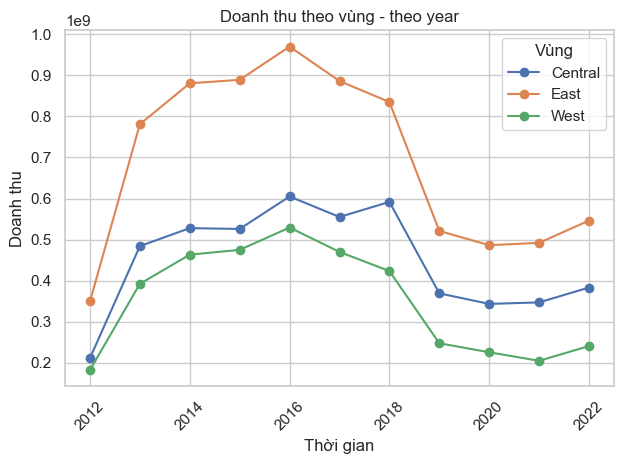

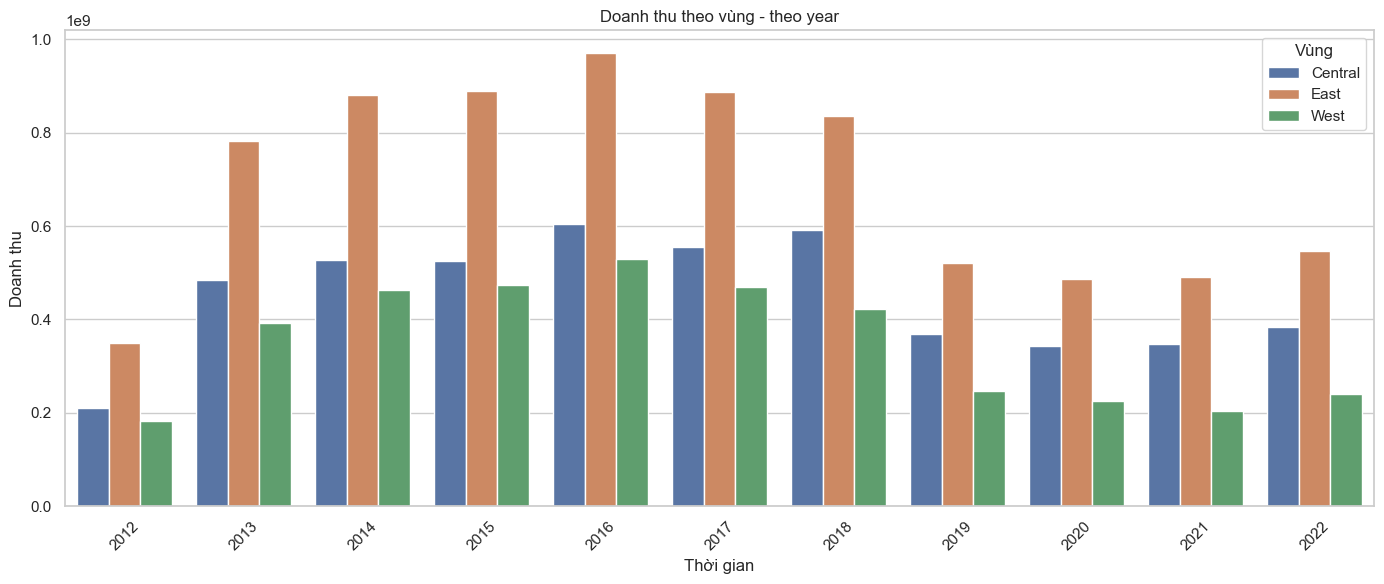

In [23]:
# In bảng
print("Doanh thu theo vùng và thời gian (đơn vị tiền):")
print(revenue_by_region_time[['region', 'time_label', 'line_revenue']].to_string(index=False))

# Vẽ biểu đồ đường
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")
pivot_df = revenue_by_region_time.pivot(index='time_label', columns='region', values='line_revenue')
pivot_df.plot(kind='line', marker='o')
plt.title(f"Doanh thu theo vùng - theo {time_level}")
plt.xlabel("Thời gian")
plt.ylabel("Doanh thu")
plt.xticks(rotation=45)
plt.legend(title='Vùng')
plt.tight_layout()
plt.show()

# Vẽ biểu đồ cột nhóm
plt.figure(figsize=(14,6))
sns.barplot(data=revenue_by_region_time, x='time_label', y='line_revenue', hue='region')
plt.title(f"Doanh thu theo vùng - theo {time_level}")
plt.xlabel("Thời gian")
plt.ylabel("Doanh thu")
plt.xticks(rotation=45)
plt.legend(title='Vùng')
plt.tight_layout()
plt.show()

# Frequency

In [24]:
## Tạo cột thời gian cho order
orders['year'] = orders['order_date'].dt.year
orders['quarter'] = orders['order_date'].dt.quarter
orders['year_quarter'] = orders['year'].astype(str) + '-Q' + orders['quarter'].astype(str)

In [38]:
## Chọn mức phân tích: 'year' hoặc 'quarter'
time_level = 'year'   # hoặc 'quarter'

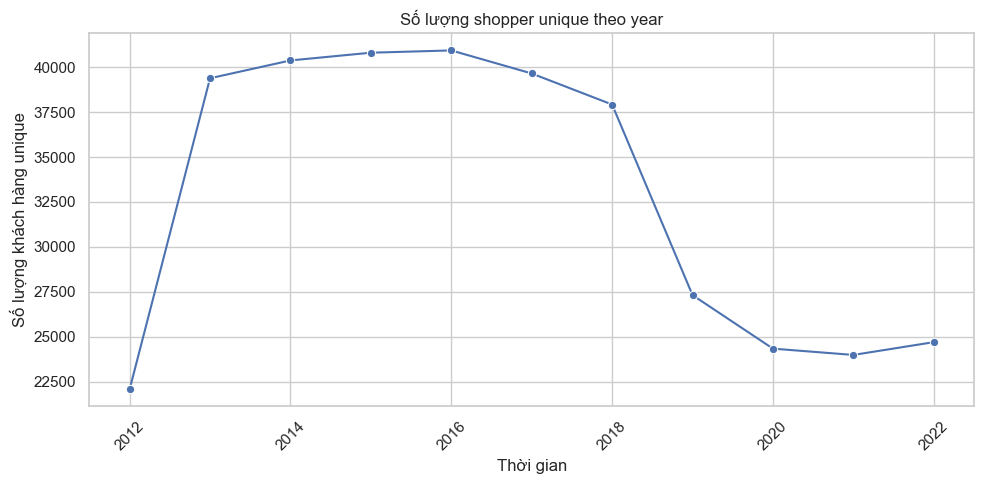

In [26]:
## Số lượng shopper unique theo từng năm/quý
if time_level == 'year':
    shopper_by_time = orders.groupby('year')['customer_id'].nunique().reset_index()
    shopper_by_time.columns = ['period', 'unique_shoppers']
    x_labels = 'year'
else:
    shopper_by_time = orders.groupby('year_quarter')['customer_id'].nunique().reset_index()
    shopper_by_time.columns = ['period', 'unique_shoppers']
    x_labels = 'year_quarter'

plt.figure(figsize=(10,5))
sns.lineplot(data=shopper_by_time, x='period', y='unique_shoppers', marker='o')
plt.title(f'Số lượng shopper unique theo {time_level}')
plt.xlabel('Thời gian')
plt.ylabel('Số lượng khách hàng unique')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
## Tỷ lệ % khách mới và cũ theo thời gian (Định nghĩa 1)

# Tạo cột period tương ứng
if time_level == 'year':
    orders['period'] = orders['year']
    period_col = 'year'  # cột dùng để groupby first_period
else:
    orders['year_quarter'] = orders['year'].astype(str) + '-Q' + orders['quarter'].astype(str)
    orders['period'] = orders['year_quarter']
    period_col = 'year_quarter'
    
# Xác định kỳ mua đầu tiên của mỗi khách
first_purchase_period = orders.groupby('customer_id')[period_col].min().reset_index()
first_purchase_period.columns = ['customer_id', 'first_period']

# Gắn first_period vào từng đơn hàng
orders_with_first = orders.merge(first_purchase_period, on='customer_id')

# Phân loại khách mới/cũ dựa trên so sánh period và first_period
orders_with_first['customer_type'] = orders_with_first.apply(
    lambda row: 'new' if row['period'] == row['first_period'] else 'existing', axis=1
)

# Đếm số lượng khách unique theo từng kỳ và loại
customer_type_count = orders_with_first.groupby(['period', 'customer_type'])['customer_id'].nunique().reset_index()

# Tạo bảng pivot để tính %
pivot_customer_type = customer_type_count.pivot(index='period', columns='customer_type', values='customer_id').fillna(0)
pivot_customer_type['total'] = pivot_customer_type['new'] + pivot_customer_type['existing']
pivot_customer_type['pct_new'] = (pivot_customer_type['new'] / pivot_customer_type['total']) * 100
pivot_customer_type['pct_existing'] = (pivot_customer_type['existing'] / pivot_customer_type['total']) * 100

# In kết quả
print(pivot_customer_type.round(2))

customer_type  existing      new    total  pct_new  pct_existing
period                                                          
2012                0.0  22068.0  22068.0   100.00          0.00
2013            14285.0  25099.0  39384.0    63.73         36.27
2014            27083.0  13293.0  40376.0    32.92         67.08
2015            31979.0   8828.0  40807.0    21.63         78.37
2016            34541.0   6392.0  40933.0    15.62         84.38
2017            34862.0   4789.0  39651.0    12.08         87.92
2018            34205.0   3717.0  37922.0     9.80         90.20
2019            25414.0   1898.0  27312.0     6.95         93.05
2020            22835.0   1500.0  24335.0     6.16         93.84
2021            22644.0   1340.0  23984.0     5.59         94.41
2022            23374.0   1322.0  24696.0     5.35         94.65


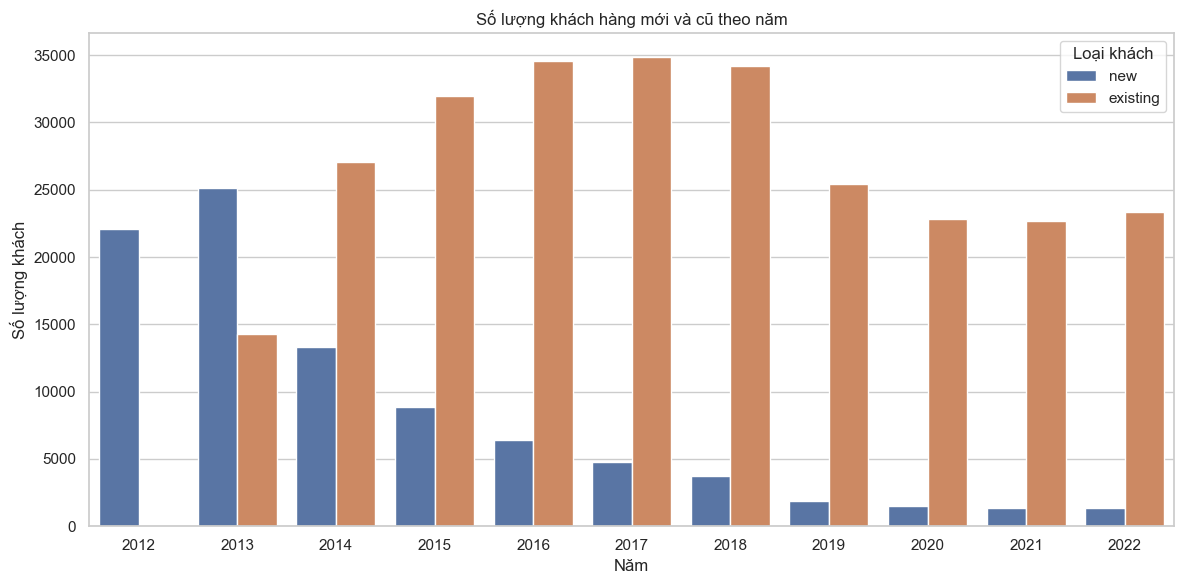

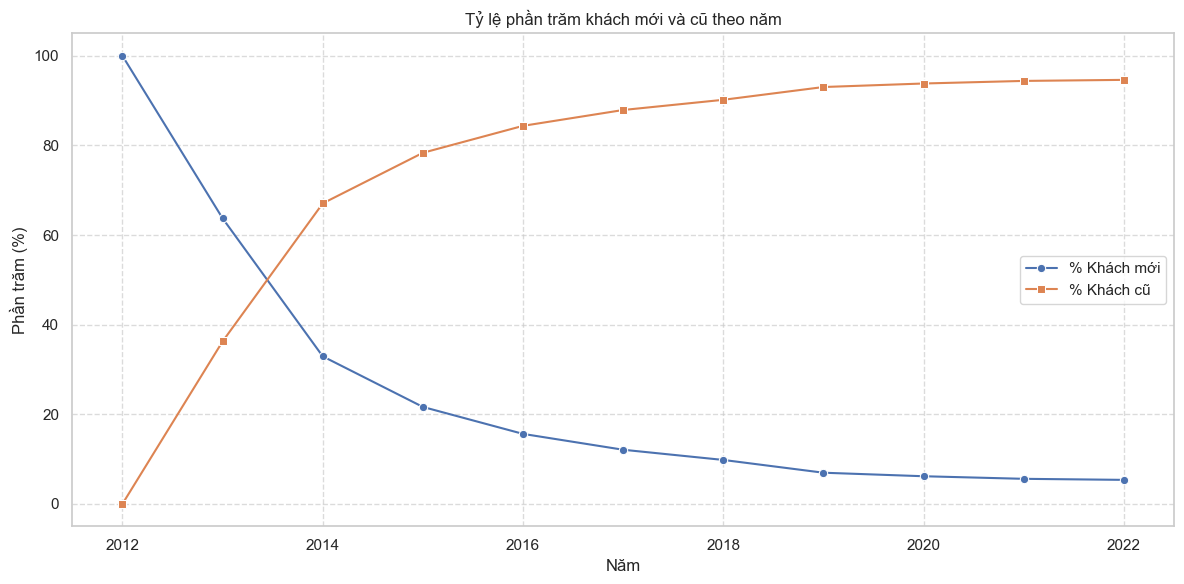

In [40]:
# Reset index để period thành cột
plot_df = pivot_customer_type.reset_index()

# Đảm bảo period là số (năm) để vẽ line chart trơn tru
plot_df['period'] = plot_df['period'].astype(int)

# --- Biểu đồ 1: Số lượng khách mới và cũ (stacked bar) ---
plt.figure(figsize=(12,6))
sns.barplot(data=plot_df.melt(id_vars='period', value_vars=['new', 'existing'], var_name='customer_type', value_name='count'),
            x='period', y='count', hue='customer_type')
plt.title('Số lượng khách hàng mới và cũ theo năm')
plt.xlabel('Năm')
plt.ylabel('Số lượng khách')
plt.legend(title='Loại khách')
plt.tight_layout()
plt.show()

# --- Biểu đồ 2: % khách mới và cũ (area chart hoặc line) ---
plt.figure(figsize=(12,6))
sns.lineplot(data=plot_df, x='period', y='pct_new', marker='o', label='% Khách mới')
sns.lineplot(data=plot_df, x='period', y='pct_existing', marker='s', label='% Khách cũ')
plt.title('Tỷ lệ phần trăm khách mới và cũ theo năm')
plt.xlabel('Năm')
plt.ylabel('Phần trăm (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [41]:
## Tỷ lệ % khách mới và cũ theo thời gian (Định nghĩa 2)

# TẠO CỬA SỔ 2 NĂM CHO TỪNG NĂM
years = sorted(orders['year'].unique())
window_results = []

for idx, year in enumerate(years):
    # Khách hàng mua trong năm hiện tại
    cust_current = set(orders[orders['year'] == year]['customer_id'])
    
    # Khách hàng mua trong 2 năm trước (năm T-2 và T-1)
    past_years = [y for y in years if y < year and (year - y) <= 2]
    cust_past = set()
    for y in past_years:
        cust_past.update(orders[orders['year'] == y]['customer_id'])
    
    # Phân loại
    existing = len(cust_current.intersection(cust_past))   # có mua trong 2 năm trước
    new = len(cust_current) - existing                     # không mua trong 2 năm trước
    total = len(cust_current)
    pct_new = (new / total * 100) if total > 0 else 0
    pct_existing = (existing / total * 100) if total > 0 else 0
    
    window_results.append({
        'period': year,
        'new': new,
        'existing': existing,
        'total': total,
        'pct_new': pct_new,
        'pct_existing': pct_existing
    })

df_window = pd.DataFrame(window_results)
print("=== KẾT QUẢ VỚI CỬA SỔ 2 NĂM ===")
print(df_window.round(2))

=== KẾT QUẢ VỚI CỬA SỔ 2 NĂM ===
    period    new  existing  total  pct_new  pct_existing
0     2012  22068         0  22068   100.00          0.00
1     2013  25099     14285  39384    63.73         36.27
2     2014  13293     27083  40376    32.92         67.08
3     2015  10231     30576  40807    25.07         74.93
4     2016   9953     30980  40933    24.32         75.68
5     2017   9310     30341  39651    23.48         76.52
6     2018   9087     28835  37922    23.96         76.04
7     2019   6100     21212  27312    22.33         77.67
8     2020   6609     17726  24335    27.16         72.84
9     2021   8372     15612  23984    34.91         65.09
10    2022   9375     15321  24696    37.96         62.04


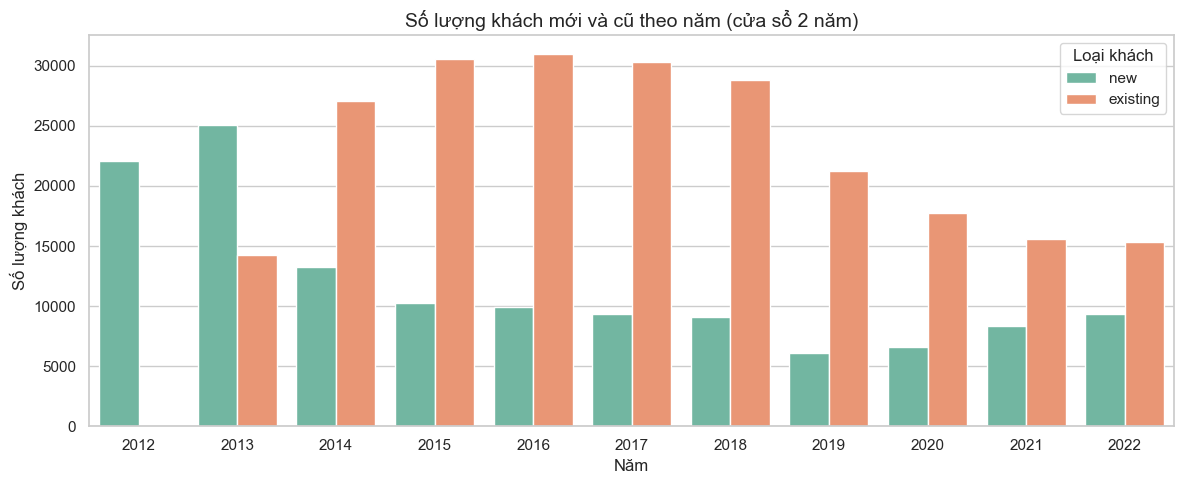

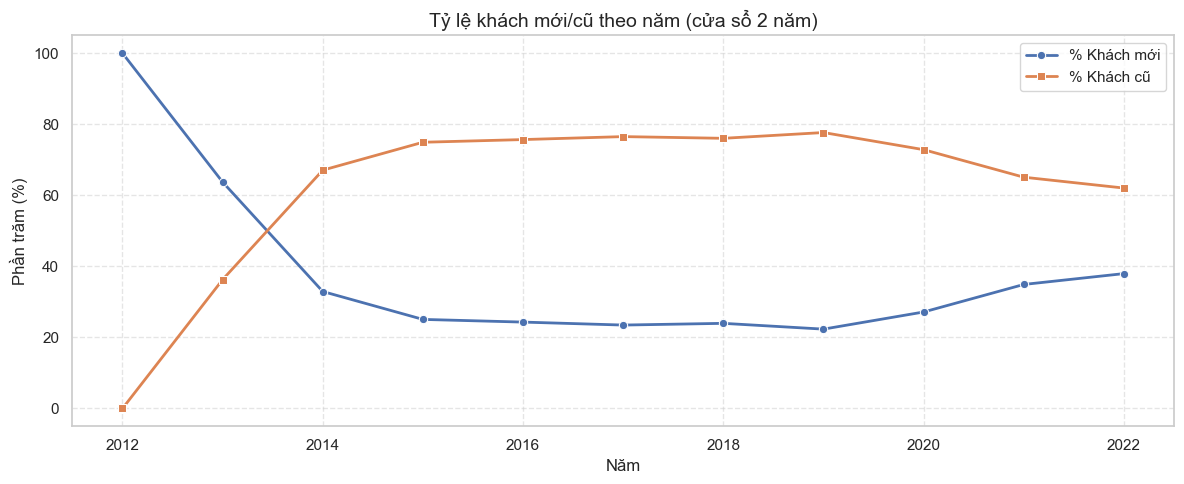

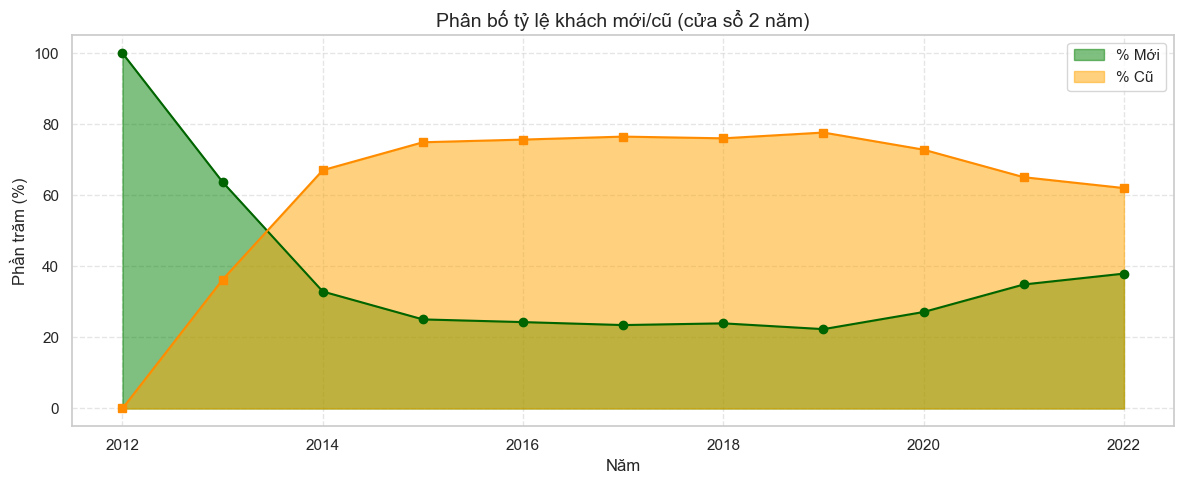

In [43]:
# Đảm bảo period là số nguyên để vẽ đường xu hướng
df_window['period'] = df_window['period'].astype(int)

# ---------- Biểu đồ 1: Số lượng khách mới và cũ (cột nhóm) ----------
plt.figure(figsize=(12,5))
df_plot = df_window.melt(id_vars='period', value_vars=['new', 'existing'], 
                         var_name='customer_type', value_name='count')
sns.barplot(data=df_plot, x='period', y='count', hue='customer_type', palette='Set2')
plt.title('Số lượng khách mới và cũ theo năm (cửa sổ 2 năm)', fontsize=14)
plt.xlabel('Năm')
plt.ylabel('Số lượng khách')
plt.legend(title='Loại khách')
plt.tight_layout()
plt.show()

# ---------- Biểu đồ 2: Tỷ lệ phần trăm (đường) ----------
plt.figure(figsize=(12,5))
sns.lineplot(data=df_window, x='period', y='pct_new', marker='o', label='% Khách mới', linewidth=2)
sns.lineplot(data=df_window, x='period', y='pct_existing', marker='s', label='% Khách cũ', linewidth=2)
plt.title('Tỷ lệ khách mới/cũ theo năm (cửa sổ 2 năm)', fontsize=14)
plt.xlabel('Năm')
plt.ylabel('Phần trăm (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---------- (Tuỳ chọn) Biểu đồ vùng (area chart) cho % ----------
plt.figure(figsize=(12,5))
plt.fill_between(df_window['period'], df_window['pct_new'], label='% Mới', alpha=0.5, color='green')
plt.fill_between(df_window['period'], df_window['pct_existing'], label='% Cũ', alpha=0.5, color='orange')
plt.plot(df_window['period'], df_window['pct_new'], marker='o', color='darkgreen')
plt.plot(df_window['period'], df_window['pct_existing'], marker='s', color='darkorange')
plt.title('Phân bố tỷ lệ khách mới/cũ (cửa sổ 2 năm)', fontsize=14)
plt.xlabel('Năm')
plt.ylabel('Phần trăm (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

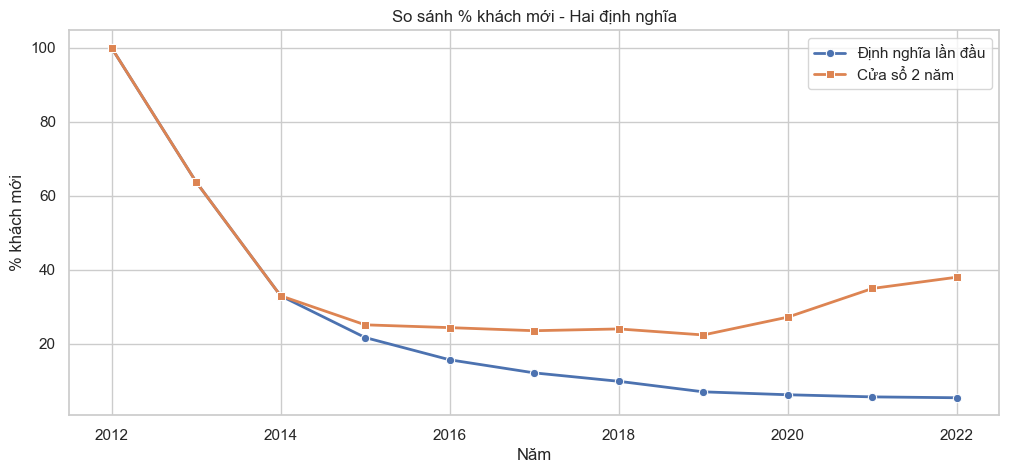

In [42]:
## So sánh khách mới ở cả 2 định nghĩa

# Giả sử bạn đã có df_window và pivot_customer_type
import matplotlib.pyplot as plt
import seaborn as sns

# Chuẩn bị dữ liệu
df_compare = pivot_customer_type[['pct_new']].rename(columns={'pct_new': 'def_first_time'}).reset_index()
df_compare = df_compare.merge(df_window[['period', 'pct_new']], on='period')
df_compare.rename(columns={'pct_new': 'def_window_2y'}, inplace=True)

# Vẽ
plt.figure(figsize=(12,5))
sns.lineplot(data=df_compare, x='period', y='def_first_time', marker='o', label='Định nghĩa lần đầu', linewidth=2)
sns.lineplot(data=df_compare, x='period', y='def_window_2y', marker='s', label='Cửa sổ 2 năm', linewidth=2)
plt.title('So sánh % khách mới - Hai định nghĩa')
plt.xlabel('Năm')
plt.ylabel('% khách mới')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
## Retention rate qua các năm

# Tính số khách cũ năm T có mua cả năm T-1
retention = {}
years = sorted(orders['year'].unique())
for i in range(1, len(years)):
    prev_year = years[i-1]
    curr_year = years[i]
    cust_prev = set(orders[orders['year']==prev_year]['customer_id'])
    cust_curr = set(orders[orders['year']==curr_year]['customer_id'])
    retained = len(cust_prev.intersection(cust_curr))
    retention[curr_year] = retained / len(cust_prev) * 100
print(retention)

{np.int32(2013): 64.73173826354903, np.int32(2014): 60.24527726995734, np.int32(2015): 60.07281553398058, np.int32(2016): 60.39650060038719, np.int32(2017): 58.95243446607872, np.int32(2018): 56.755189024236465, np.int32(2019): 43.47871947682084, np.int32(2020): 42.33304042179262, np.int32(2021): 43.02855968769263, np.int32(2022): 44.55887258172115}


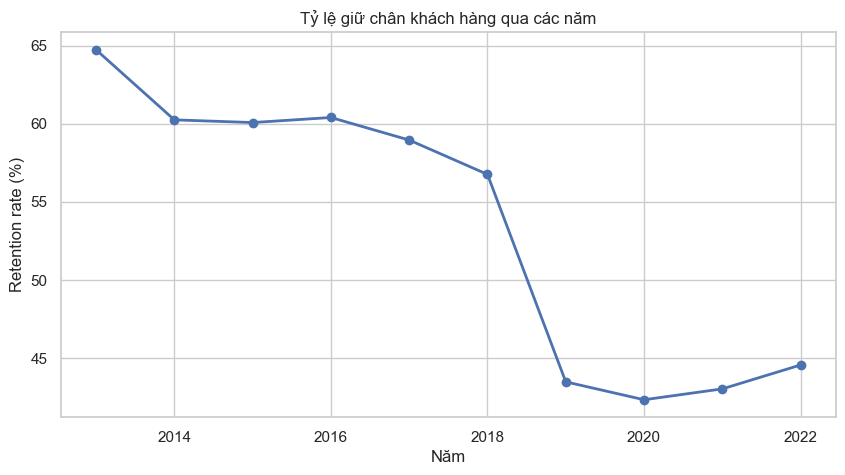

In [44]:
ret_df = pd.DataFrame(list(retention.items()), columns=['year', 'retention_rate'])
plt.figure(figsize=(10,5))
plt.plot(ret_df['year'], ret_df['retention_rate'], marker='o', linewidth=2)
plt.title('Tỷ lệ giữ chân khách hàng qua các năm')
plt.xlabel('Năm')
plt.ylabel('Retention rate (%)')
plt.grid(True)
plt.show()

=== Inter-order gap trung vị theo year (chỉ giữ kỳ có >= 5 gap) ===
 period  median_gap_days
   2012             33.0
   2013             77.0
   2014            106.0
   2015            118.0
   2016            123.0
   2017            141.0
   2018            156.0
   2019            253.0
   2020            320.0
   2021            336.0
   2022            333.0


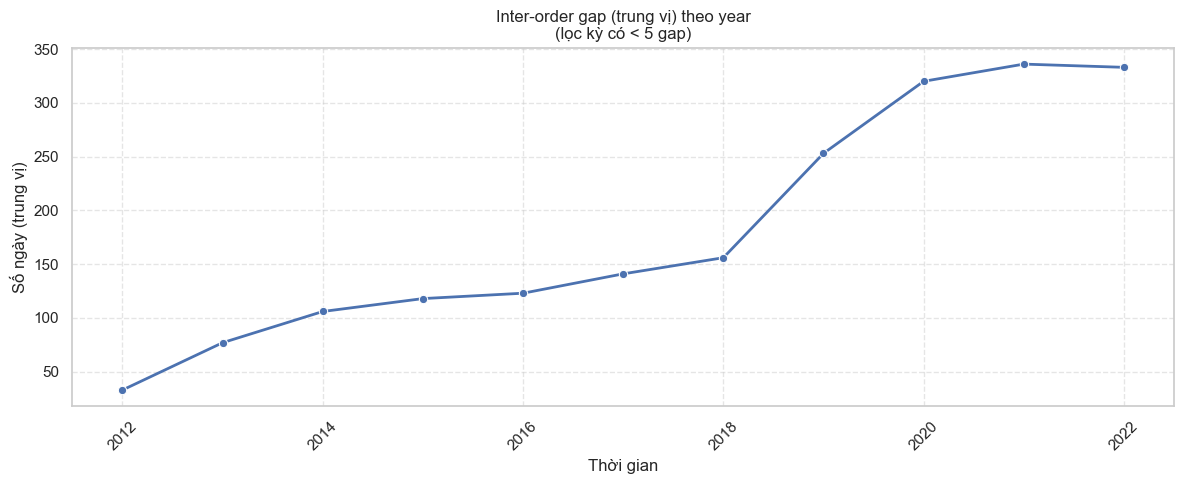

In [45]:
### Inter-order gap trung vị theo thời gian

# ============================================================
# 1. CHUẨN BỊ DỮ LIỆU
# ============================================================
# Giả sử orders đã có cột 'order_date' dạng datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Tạo cột năm, quý, year_quarter
orders['year'] = orders['order_date'].dt.year
orders['quarter'] = orders['order_date'].dt.quarter
orders['year_quarter'] = orders['year'].astype(str) + '-Q' + orders['quarter'].astype(str)

# ============================================================
# 2. THAM SỐ ĐẦU VÀO
# ============================================================
time_level = 'year'        # 'year' hoặc 'quarter'
min_gap_count = 5          # ngưỡng lọc: chỉ giữ kỳ có >= 5 gap

# ============================================================
# 3. TÍNH GAP CHO TỪNG KHÁCH HÀNG (CHỈ KHÁCH >= 2 ĐƠN)
# ============================================================
# Lọc khách có ít nhất 2 đơn
order_counts = orders.groupby('customer_id').size()
multi_customers = order_counts[order_counts >= 2].index
orders_multi = orders[orders['customer_id'].isin(multi_customers)].copy()

# Sắp xếp và tính gap (ngày)
orders_multi = orders_multi.sort_values(['customer_id', 'order_date'])
orders_multi['gap'] = orders_multi.groupby('customer_id')['order_date'].diff().dt.days

# Bỏ các dòng đầu tiên của mỗi khách (gap = NaN)
gaps = orders_multi.dropna(subset=['gap']).copy()

# ============================================================
# 4. GÁN KỲ (PERIOD) TƯƠNG ỨNG CHO MỖI GAP (THEO order_date SAU)
# ============================================================
if time_level == 'year':
    gaps['period'] = gaps['year']
else:
    gaps['period'] = gaps['year_quarter']

# ============================================================
# 5. LỌC CÁC KỲ CÓ SỐ LƯỢNG GAP >= min_gap_count
# ============================================================
gap_counts = gaps.groupby('period').size().reset_index(name='count')
valid_periods = gap_counts[gap_counts['count'] >= min_gap_count]['period']
gaps_filtered = gaps[gaps['period'].isin(valid_periods)]

# ============================================================
# 6. TÍNH TRUNG VỊ THEO TỪNG KỲ
# ============================================================
median_gap = gaps_filtered.groupby('period')['gap'].median().reset_index()
median_gap.columns = ['period', 'median_gap_days']

# Sắp xếp theo thứ tự thời gian (quan trọng cho quý)
if time_level == 'year':
    median_gap = median_gap.sort_values('period')
else:
    # Với quý, cần sắp xếp theo năm và quý
    median_gap['sort_key'] = median_gap['period'].apply(lambda x: (int(x.split('-Q')[0]), int(x.split('-Q')[1])))
    median_gap = median_gap.sort_values('sort_key').drop('sort_key', axis=1)

# ============================================================
# 7. HIỂN THỊ KẾT QUẢ
# ============================================================
print(f"=== Inter-order gap trung vị theo {time_level} (chỉ giữ kỳ có >= {min_gap_count} gap) ===")
print(median_gap.to_string(index=False))

# ============================================================
# 8. VẼ BIỂU ĐỒ (TÙY CHỌN)
# ============================================================
plt.figure(figsize=(12, 5))
sns.lineplot(data=median_gap, x='period', y='median_gap_days', marker='o', linewidth=2)
plt.title(f'Inter-order gap (trung vị) theo {time_level}\n(lọc kỳ có < {min_gap_count} gap)')
plt.xlabel('Thời gian')
plt.ylabel('Số ngày (trung vị)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Promo - median gap (chỉ các năm có cả hai nhóm đủ dữ liệu):
   period  median_gap_days
0    2013             64.0
1    2014            178.0
2    2015            187.0
3    2016            264.0
4    2017            273.0
5    2018            351.0
6    2019            467.0
7    2020            627.0
8    2021            716.0
9    2022            737.0

Non-promo:
    period  median_gap_days
1     2013            106.0
2     2014            150.0
3     2015            200.0
4     2016            187.0
5     2017            243.0
6     2018            260.0
7     2019            336.0
8     2020            483.0
9     2021            512.0
10    2022            536.0


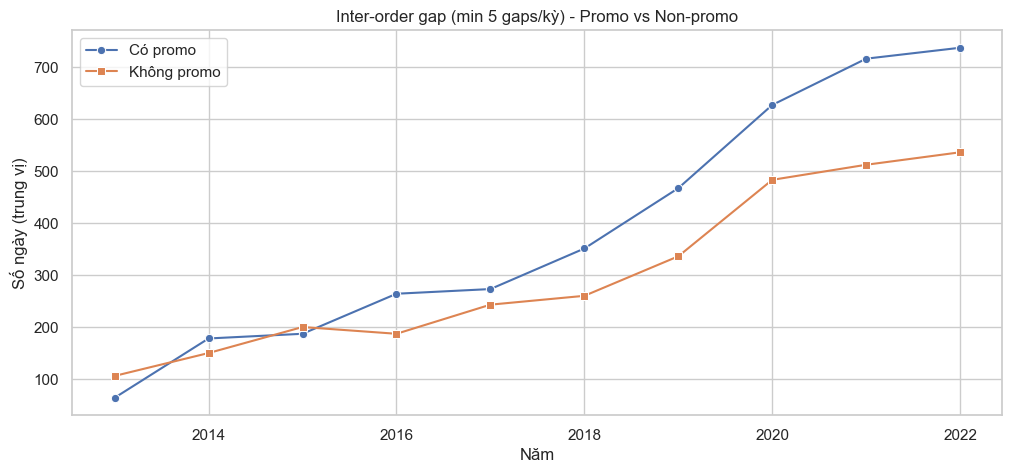

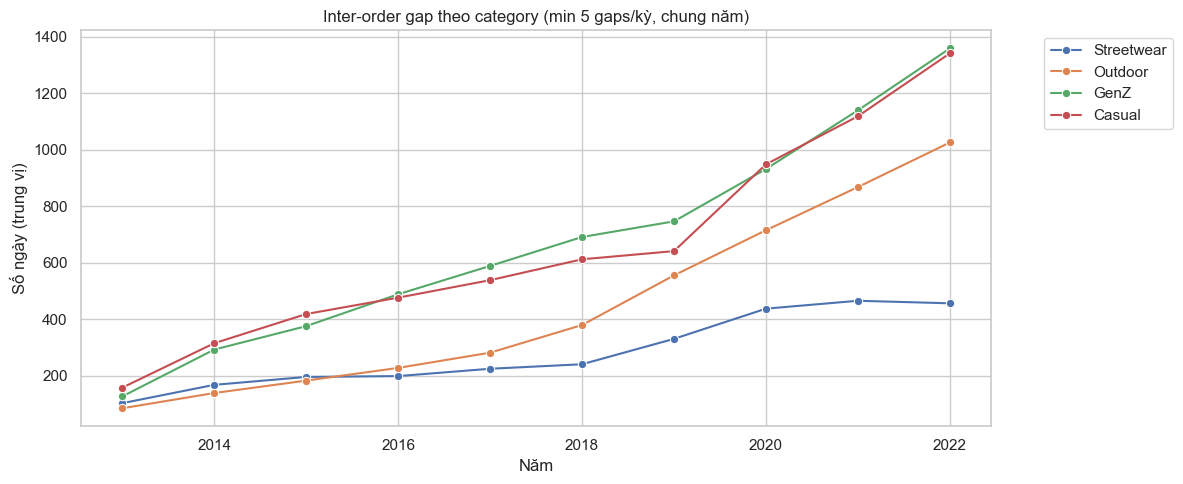

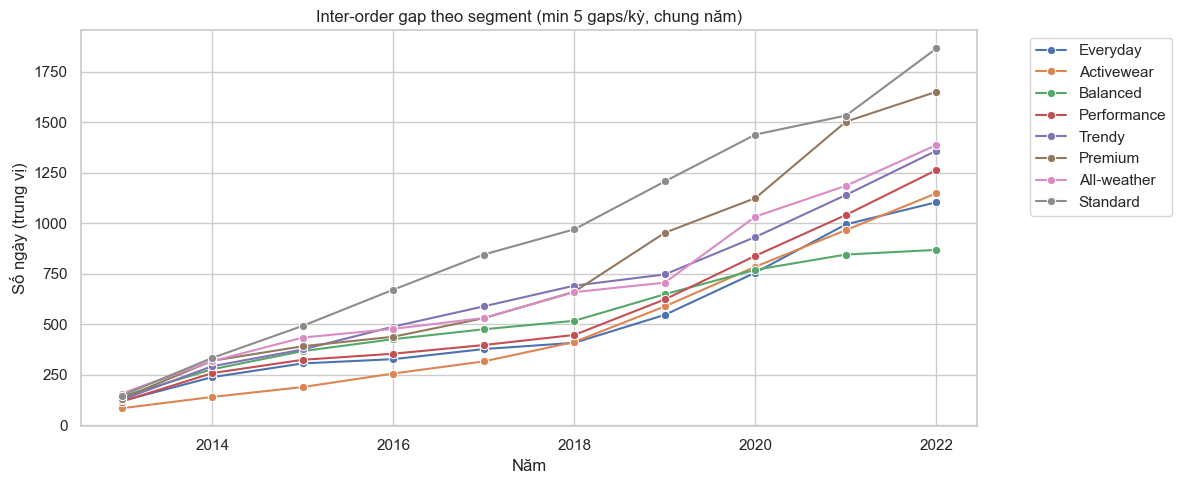

In [48]:
# =====================================================
# HÀM TÍNH INTER-ORDER GAP VỚI NGƯỠNG CỐ ĐỊNH = 5
# =====================================================
def compute_median_gap(orders_subset, time_level='year', min_gap_count=5):
    """
    orders_subset : DataFrame có cột 'customer_id', 'order_date'
    time_level    : 'year' hoặc 'quarter'
    min_gap_count : số gap tối thiểu để giữ một kỳ
    Trả về DataFrame: period, median_gap_days, gap_count
    """
    temp = orders_subset[['customer_id', 'order_date']].copy()
    temp['order_date'] = pd.to_datetime(temp['order_date'])
    
    if time_level == 'year':
        temp['period'] = temp['order_date'].dt.year
    else:
        temp['quarter'] = temp['order_date'].dt.quarter
        temp['period'] = temp['order_date'].dt.year.astype(str) + '-Q' + temp['quarter'].astype(str)
    
    temp = temp.sort_values(['customer_id', 'order_date'])
    temp['gap'] = temp.groupby('customer_id')['order_date'].diff().dt.days
    gaps = temp.dropna(subset=['gap']).copy()
    
    gap_counts = gaps.groupby('period').size().rename('gap_count')
    median_gap = gaps.groupby('period')['gap'].median().rename('median_gap_days')
    
    result = pd.DataFrame({'median_gap_days': median_gap, 'gap_count': gap_counts}).reset_index()
    result = result[result['gap_count'] >= min_gap_count]
    return result

# =====================================================
# 1. GẮN NHÃN PROMO, CATEGORY, SEGMENT CHO ORDERS (GIỮ NGUYÊN TÊN RÕ RÀNG)
# =====================================================
# Tạo flag promo cho từng order
order_promo_flag = order_items.groupby('order_id')['promo_id'].apply(
    lambda x: x.notna().any()
).reset_index(name='has_promo')

orders_with_promo = orders.merge(order_promo_flag, on='order_id', how='left')
orders_with_promo['has_promo'] = orders_with_promo['has_promo'].fillna(False)

# Gán category và segment (lấy giá trị đầu tiên)
order_items_prod = order_items.merge(
    products[['product_id', 'category', 'segment']],
    on='product_id', how='left'
)
order_category = order_items_prod.groupby('order_id')['category'].first().reset_index()
order_category.columns = ['order_id', 'order_category']
order_segment = order_items_prod.groupby('order_id')['segment'].first().reset_index()
order_segment.columns = ['order_id', 'order_segment']

orders_final = orders_with_promo.merge(order_category, on='order_id', how='left')
orders_final = orders_final.merge(order_segment, on='order_id', how='left')

# =====================================================
# 2. PHÂN TÍCH VỚI NGƯỠNG NHẤT QUÁN min_gap_count = 5
# =====================================================
MIN_GAP = 5  # cố định cho mọi nhóm

# ---- a) Promo vs Non-promo ----
orders_promo = orders_final[orders_final['has_promo'] == True]
orders_non_promo = orders_final[orders_final['has_promo'] == False]

median_promo = compute_median_gap(orders_promo, time_level='year', min_gap_count=MIN_GAP)
median_non_promo = compute_median_gap(orders_non_promo, time_level='year', min_gap_count=MIN_GAP)

# Chỉ lấy các năm có cả hai nhóm đủ gap
common_years = set(median_promo['period']).intersection(median_non_promo['period'])
median_promo = median_promo[median_promo['period'].isin(common_years)]
median_non_promo = median_non_promo[median_non_promo['period'].isin(common_years)]

print("Promo - median gap (chỉ các năm có cả hai nhóm đủ dữ liệu):")
print(median_promo[['period', 'median_gap_days']])
print("\nNon-promo:")
print(median_non_promo[['period', 'median_gap_days']])

# Vẽ so sánh
plt.figure(figsize=(12,5))
sns.lineplot(data=median_promo, x='period', y='median_gap_days', marker='o', label='Có promo')
sns.lineplot(data=median_non_promo, x='period', y='median_gap_days', marker='s', label='Không promo')
plt.title(f'Inter-order gap (min {MIN_GAP} gaps/kỳ) - Promo vs Non-promo')
plt.xlabel('Năm')
plt.ylabel('Số ngày (trung vị)')
plt.legend()
plt.grid(True)
plt.show()

# ---- b) Theo Category ----
# Chỉ giữ các category có ít nhất 100 đơn để tránh quá ít dữ liệu
category_counts = orders_final['order_category'].value_counts()
valid_categories = category_counts[category_counts >= 100].index

median_by_category = {}
for cat in valid_categories:
    sub_orders = orders_final[orders_final['order_category'] == cat]
    median_cat = compute_median_gap(sub_orders, time_level='year', min_gap_count=MIN_GAP)
    if not median_cat.empty:
        median_by_category[cat] = median_cat

# Tìm tập năm chung cho tất cả các category
if median_by_category:
    common_years_cat = set.intersection(*[set(df['period']) for df in median_by_category.values()])
    filtered_cat = {}
    for cat, df_cat in median_by_category.items():
        df_filtered = df_cat[df_cat['period'].isin(common_years_cat)]
        if not df_filtered.empty:
            filtered_cat[cat] = df_filtered
    
    if filtered_cat:
        plt.figure(figsize=(12,5))
        for cat, df_cat in filtered_cat.items():
            sns.lineplot(data=df_cat, x='period', y='median_gap_days', marker='o', label=cat)
        plt.title(f'Inter-order gap theo category (min {MIN_GAP} gaps/kỳ, chung năm)')
        plt.xlabel('Năm')
        plt.ylabel('Số ngày (trung vị)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("Không có năm nào chung đủ dữ liệu cho các category.")
else:
    print("Không đủ category thỏa mãn điều kiện có ít nhất 100 đơn.")

# ---- c) Theo Segment - tương tự ----
segment_counts = orders_final['order_segment'].value_counts()
valid_segments = segment_counts[segment_counts >= 100].index

median_by_segment = {}
for seg in valid_segments:
    sub_orders = orders_final[orders_final['order_segment'] == seg]
    median_seg = compute_median_gap(sub_orders, time_level='year', min_gap_count=MIN_GAP)
    if not median_seg.empty:
        median_by_segment[seg] = median_seg

if median_by_segment:
    common_years_seg = set.intersection(*[set(df['period']) for df in median_by_segment.values()])
    filtered_seg = {}
    for seg, df_seg in median_by_segment.items():
        df_filtered = df_seg[df_seg['period'].isin(common_years_seg)]
        if not df_filtered.empty:
            filtered_seg[seg] = df_filtered
    
    if filtered_seg:
        plt.figure(figsize=(12,5))
        for seg, df_seg in filtered_seg.items():
            sns.lineplot(data=df_seg, x='period', y='median_gap_days', marker='o', label=seg)
        plt.title(f'Inter-order gap theo segment (min {MIN_GAP} gaps/kỳ, chung năm)')
        plt.xlabel('Năm')
        plt.ylabel('Số ngày (trung vị)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("Không có năm nào chung đủ dữ liệu cho các segment.")
else:
    print("Không đủ segment thỏa mãn điều kiện có ít nhất 100 đơn.")

In [49]:
## Repeat rate

# =====================================================
# 1. REPEAT RATE TỔNG THỂ (TOÀN BỘ LỊCH SỬ)
# =====================================================
# Đếm số đơn cho mỗi khách
order_counts = orders.groupby('customer_id').size().reset_index(name='num_orders')
total_customers = len(order_counts)
repeat_customers = (order_counts['num_orders'] >= 2).sum()
repeat_rate_overall = repeat_customers / total_customers * 100

print("=== REPEAT RATE TỔNG THỂ ===")
print(f"Tổng số khách hàng: {total_customers}")
print(f"Số khách mua từ 2 lần trở lên: {repeat_customers}")
print(f"Repeat rate: {repeat_rate_overall:.2f}%")

# =====================================================
# 2. REPEAT RATE THEO COHORT NĂM ĐẦU TIÊN
# (tỷ lệ khách mua lần đầu trong năm đó có mua ít nhất 1 lần nữa trong tương lai)
# =====================================================
# Xác định năm đầu tiên của mỗi khách
first_purchase = orders.groupby('customer_id')['order_date'].min().reset_index()
first_purchase['cohort_year'] = first_purchase['order_date'].dt.year

# Gắn cohort_year vào orders
orders_with_cohort = orders.merge(first_purchase[['customer_id', 'cohort_year']], on='customer_id')

# Với mỗi cohort_year, xác định những khách có ít nhất 2 đơn (bất kỳ thời điểm nào sau đó)
cohort_repeat = orders_with_cohort.groupby('cohort_year').apply(
    lambda df: (df.groupby('customer_id').size() >= 2).sum()
).reset_index(name='repeat_customers')

cohort_total = first_purchase.groupby('cohort_year').size().reset_index(name='total_customers')
cohort_stats = cohort_total.merge(cohort_repeat, on='cohort_year', how='left')
cohort_stats['repeat_rate'] = cohort_stats['repeat_customers'] / cohort_stats['total_customers'] * 100

print("\n=== REPEAT RATE THEO COHORT (NĂM ĐẦU TIÊN) ===")
print(cohort_stats[['cohort_year', 'total_customers', 'repeat_customers', 'repeat_rate']].round(2))

# =====================================================
# 3. (Tuỳ chọn) REPEAT RATE TRONG VÒNG 12 THÁNG KỂ TỪ LẦN ĐẦU
# (chỉ tính lần mua thứ hai nếu xảy ra trong 365 ngày)
# =====================================================
# Lấy lần mua đầu và lần mua thứ hai
first_orders = orders.sort_values(['customer_id', 'order_date']).groupby('customer_id').first().reset_index()
second_orders = orders.sort_values(['customer_id', 'order_date']).groupby('customer_id').nth(1).reset_index()

# Gộp để tính khoảng cách
repeat_12m = second_orders.merge(first_orders[['customer_id', 'order_date']], 
                                  on='customer_id', suffixes=('_second', '_first'))
repeat_12m['days_to_second'] = (repeat_12m['order_date_second'] - repeat_12m['order_date_first']).dt.days
repeat_12m['repeat_within_12m'] = repeat_12m['days_to_second'] <= 365

# Tính tỷ lệ theo cohort năm đầu
repeat_12m_with_cohort = repeat_12m.merge(first_purchase[['customer_id', 'cohort_year']], on='customer_id')
cohort_12m = repeat_12m_with_cohort.groupby('cohort_year')['repeat_within_12m'].mean().reset_index()
cohort_12m.columns = ['cohort_year', 'repeat_rate_12m']

print("\n=== REPEAT RATE TRONG VÒNG 12 THÁNG (THEO COHORT) ===")
print(cohort_12m.round(4) * 100)

=== REPEAT RATE TỔNG THỂ ===
Tổng số khách hàng: 90246
Số khách mua từ 2 lần trở lên: 67888
Repeat rate: 75.23%


C:\Users\NganNguyen's laptop\AppData\Local\Temp\ipykernel_20460\3721655063.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cohort_repeat = orders_with_cohort.groupby('cohort_year').apply(



=== REPEAT RATE THEO COHORT (NĂM ĐẦU TIÊN) ===
    cohort_year  total_customers  repeat_customers  repeat_rate
0          2012            22068             20953        94.95
1          2013            25099             22535        89.78
2          2014            13293             10488        78.90
3          2015             8828              6052        68.55
4          2016             6392              3576        55.94
5          2017             4789              2087        43.58
6          2018             3717              1244        33.47
7          2019             1898               459        24.18
8          2020             1500               271        18.07
9          2021             1340               157        11.72
10         2022             1322                66         4.99

=== REPEAT RATE TRONG VÒNG 12 THÁNG (THEO COHORT) ===
    cohort_year  repeat_rate_12m
0        201200            69.15
1        201300            57.76
2        201400            46.

C:\Users\NganNguyen's laptop\AppData\Local\Temp\ipykernel_20460\3244108132.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cohort, x='cohort_year', y='repeat_rate', palette='Blues_d')


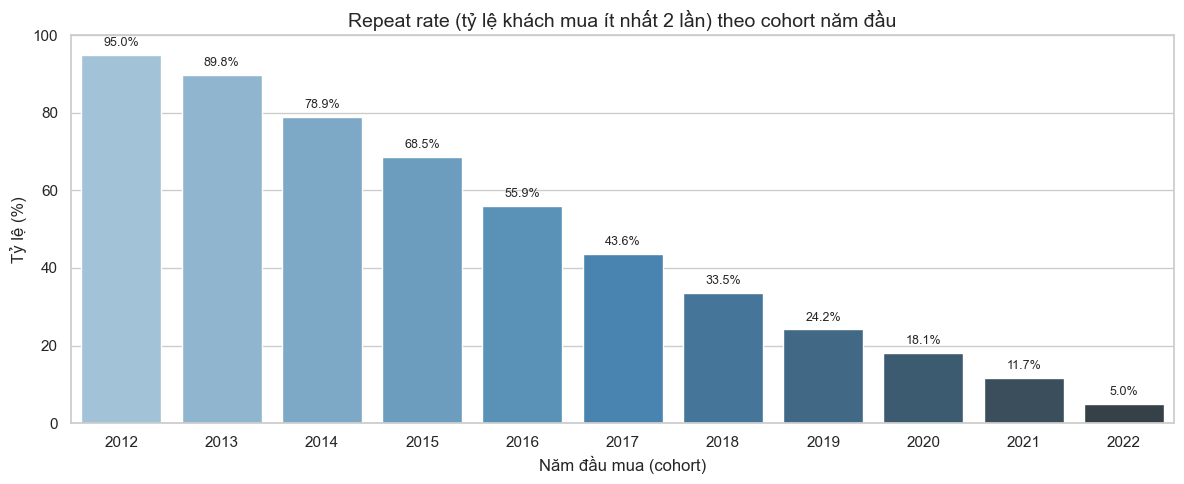

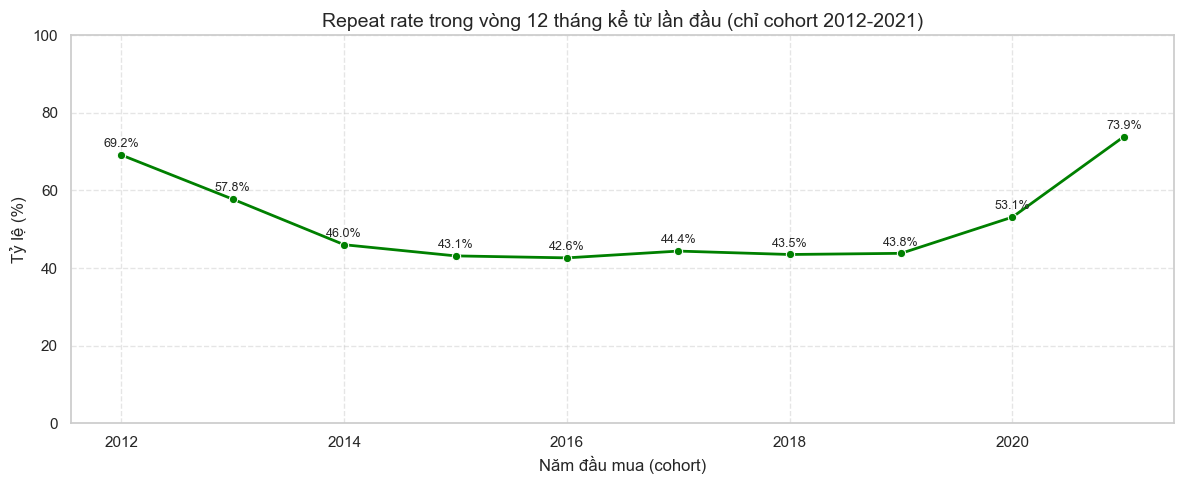

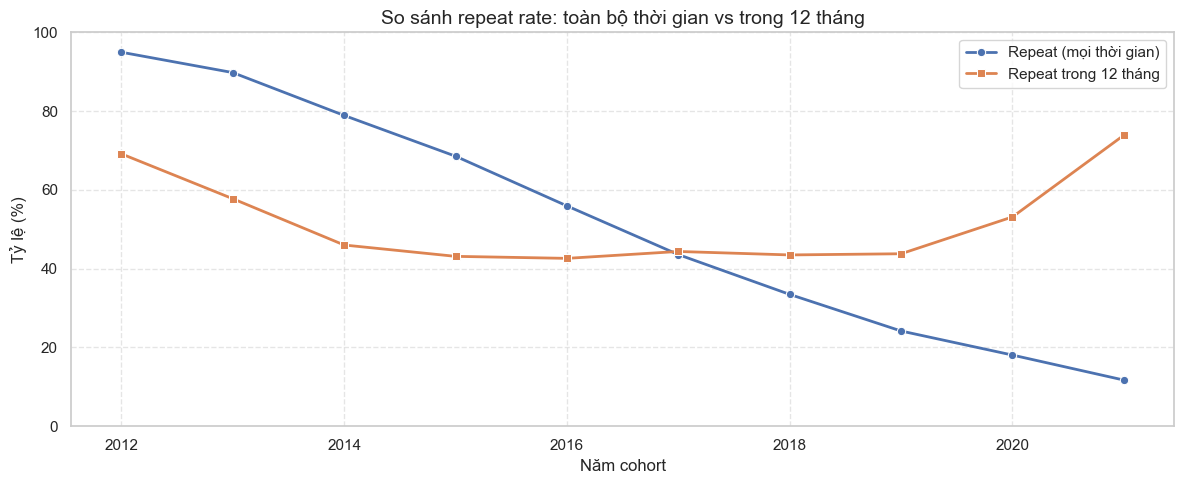

In [50]:
# ---------- TẠO LẠI DỮ LIỆU TỪ KẾT QUẢ ĐÃ CÓ ----------
# (Nếu bạn đã có sẵn hai DataFrame thì bỏ qua bước này)
data_cohort = {
    'cohort_year': [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
    'repeat_rate': [94.95, 89.78, 78.90, 68.55, 55.94, 43.58, 33.47, 24.18, 18.07, 11.72, 4.99]
}
df_cohort = pd.DataFrame(data_cohort)

data_12m = {
    'cohort_year': [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
    'repeat_rate_12m': [69.15, 57.76, 46.01, 43.13, 42.62, 44.37, 43.49, 43.79, 53.14, 73.89, 100.00]
}
df_12m = pd.DataFrame(data_12m)

# Lọc bỏ cohort 2022 cho biểu đồ 12 tháng (dữ liệu chưa đủ)
df_12m_filtered = df_12m[df_12m['cohort_year'] < 2022].copy()

# ---------- BIỂU ĐỒ 1: REPEAT RATE TOÀN BỘ THỜI GIAN ----------
plt.figure(figsize=(12, 5))
sns.barplot(data=df_cohort, x='cohort_year', y='repeat_rate', palette='Blues_d')
plt.title('Repeat rate (tỷ lệ khách mua ít nhất 2 lần) theo cohort năm đầu', fontsize=14)
plt.xlabel('Năm đầu mua (cohort)')
plt.ylabel('Tỷ lệ (%)')
plt.ylim(0, 100)
for i, v in enumerate(df_cohort['repeat_rate']):
    plt.text(i, v + 1.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# ---------- BIỂU ĐỒ 2: REPEAT RATE TRONG 12 THÁNG (CHỈ COHORT 2012-2021) ----------
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_12m_filtered, x='cohort_year', y='repeat_rate_12m', 
             marker='o', linewidth=2, color='green')
plt.title('Repeat rate trong vòng 12 tháng kể từ lần đầu (chỉ cohort 2012-2021)', fontsize=14)
plt.xlabel('Năm đầu mua (cohort)')
plt.ylabel('Tỷ lệ (%)')
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
for _, row in df_12m_filtered.iterrows():
    plt.text(row['cohort_year'], row['repeat_rate_12m'] + 2, 
             f"{row['repeat_rate_12m']:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# ---------- BIỂU ĐỒ 3: SO SÁNH HAI CHỈ SỐ ----------
# (chỉ vẽ chung các cohort có dữ liệu 12 tháng đáng tin – 2012..2021)
df_compare = df_cohort[df_cohort['cohort_year'] < 2022].merge(
    df_12m_filtered, on='cohort_year', how='inner'
)
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_compare, x='cohort_year', y='repeat_rate', 
             marker='o', label='Repeat (mọi thời gian)', linewidth=2)
sns.lineplot(data=df_compare, x='cohort_year', y='repeat_rate_12m', 
             marker='s', label='Repeat trong 12 tháng', linewidth=2)
plt.title('So sánh repeat rate: toàn bộ thời gian vs trong 12 tháng', fontsize=14)
plt.xlabel('Năm cohort')
plt.ylabel('Tỷ lệ (%)')
plt.ylim(0, 100)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [51]:
##  Tính cohort retention (theo năm)

# Giả sử orders đã có cột 'customer_id', 'order_date', 'year'
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['year'] = orders['order_date'].dt.year

# Xác định năm đầu tiên của mỗi khách
first_purchase = orders.groupby('customer_id')['year'].min().reset_index()
first_purchase.columns = ['customer_id', 'cohort_year']

# Gắn cohort_year vào orders
orders_cohort = orders.merge(first_purchase, on='customer_id')

# Tạo cột năm chênh lệch (số năm kể từ cohort_year)
orders_cohort['year_diff'] = orders_cohort['year'] - orders_cohort['cohort_year']

# Tính số khách duy nhất trong mỗi cohort_year và year_diff
cohort_data = orders_cohort.groupby(['cohort_year', 'year_diff'])['customer_id'].nunique().reset_index()

# Lấy tổng số khách ban đầu của mỗi cohort
cohort_size = cohort_data[cohort_data['year_diff'] == 0][['cohort_year', 'customer_id']]
cohort_size.columns = ['cohort_year', 'cohort_total']

# Ghép và tính retention rate (%)
cohort_retention = cohort_data.merge(cohort_size, on='cohort_year')
cohort_retention['retention_rate'] = (cohort_retention['customer_id'] / cohort_retention['cohort_total']) * 100

# Pivot để dễ nhìn (hàng: cohort_year, cột: year_diff, giá trị: retention_rate)
retention_matrix = cohort_retention.pivot(index='cohort_year', columns='year_diff', values='retention_rate')
retention_matrix = retention_matrix.round(1)

print("=== MA TRẬN COHORT RETENTION (% khách vẫn mua sau N năm) ===")
print(retention_matrix)

=== MA TRẬN COHORT RETENTION (% khách vẫn mua sau N năm) ===
year_diff       0     1     2     3     4     5     6     7     8     9     10
cohort_year                                                                   
2012         100.0  64.7  65.0  65.6  65.9  63.9  61.9  47.6  43.0  42.6  43.6
2013         100.0  50.8  51.1  50.9  49.5  47.4  35.0  31.2  30.7  31.8   NaN
2014         100.0  35.1  36.0  34.1  32.5  22.4  19.9  19.2  20.2   NaN   NaN
2015         100.0  27.4  27.7  25.5  16.4  14.2  14.6  14.8   NaN   NaN   NaN
2016         100.0  21.2  20.4  12.6  11.4  10.7  11.1   NaN   NaN   NaN   NaN
2017         100.0  16.1  11.7   9.3   9.7   8.7   NaN   NaN   NaN   NaN   NaN
2018         100.0   9.4   8.3   8.1   8.4   NaN   NaN   NaN   NaN   NaN   NaN
2019         100.0   7.6   7.2   7.3   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2020         100.0   6.8   7.1   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2021         100.0   6.7   NaN   NaN   NaN   NaN   NaN   NaN   NaN   N

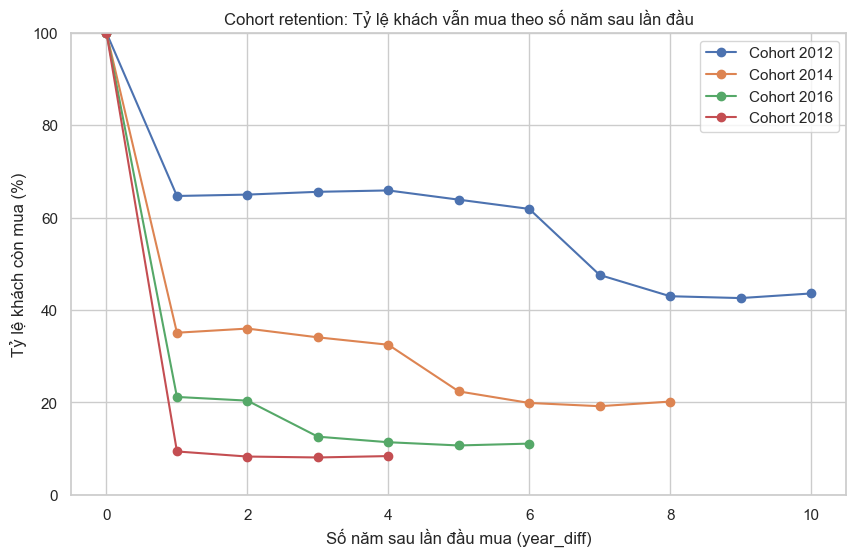

In [52]:
# Chọn các cohort có đủ số năm quan sát (ví dụ 2012-2018)
plot_cohorts = [2012, 2014, 2016, 2018]
plt.figure(figsize=(10, 6))
for cohort in plot_cohorts:
    if cohort in retention_matrix.index:
        data = retention_matrix.loc[cohort].dropna()
        plt.plot(data.index, data.values, marker='o', label=f'Cohort {cohort}')
plt.title('Cohort retention: Tỷ lệ khách vẫn mua theo số năm sau lần đầu')
plt.xlabel('Số năm sau lần đầu mua (year_diff)')
plt.ylabel('Tỷ lệ khách còn mua (%)')
plt.ylim(0, 100)
plt.legend()
plt.grid(True)
plt.show()

# Traffic

=== Thống kê web traffic theo quý ===
  year_quarter  total_page_views  total_unique_visitors
0      2013-Q1           5797008                1018918
1      2013-Q2          10644684                1846872
2      2013-Q3           7924583                1416442
3      2013-Q4           5037383                 884269
4      2014-Q1           6312238                1097129
5      2014-Q2          11385556                2009190
6      2014-Q3           8908871                1540097
7      2014-Q4           5340542                 949832
8      2015-Q1           6712528                1178084
9      2015-Q2          12231917                2111247


C:\Users\NganNguyen's laptop\AppData\Local\Temp\ipykernel_7700\2410732416.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(quarterly_stats['year_quarter'], rotation=45, ha='right')


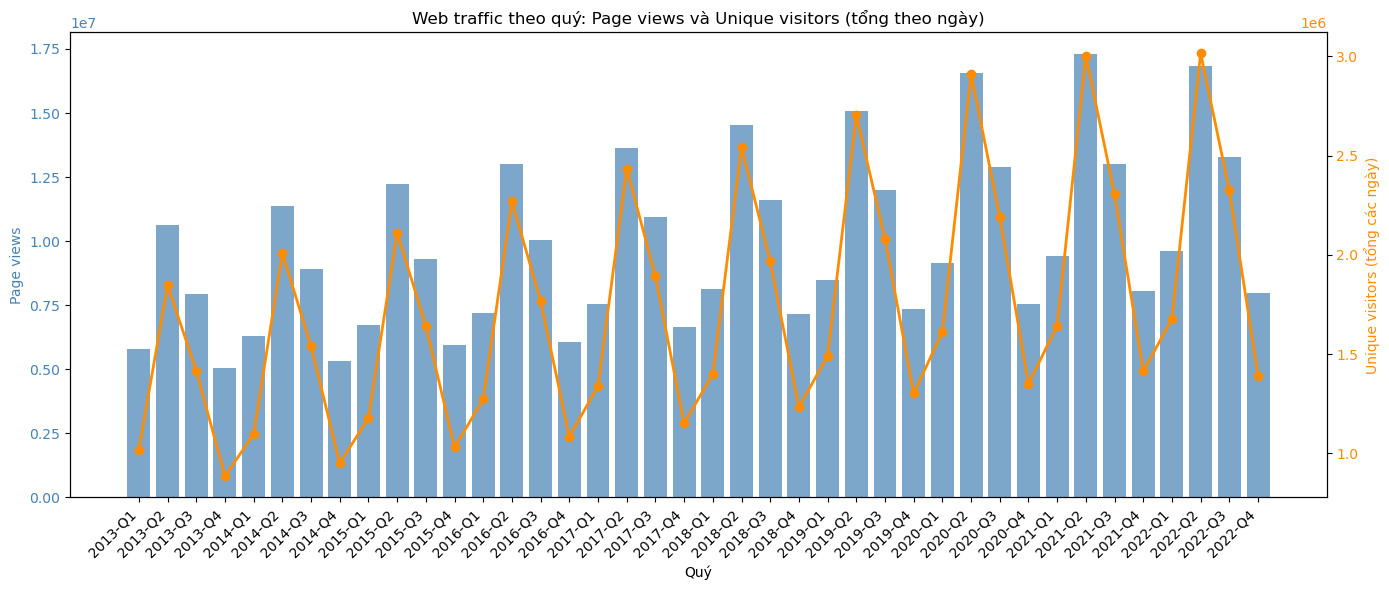

In [8]:
web['date'] = pd.to_datetime(web['date'])

# Tạo cột năm, quý
web['year'] = web['date'].dt.year
web['quarter'] = web['date'].dt.quarter
web['year_quarter'] = web['year'].astype(str) + '-Q' + web['quarter'].astype(str)

# Tổng hợp theo quý
quarterly_stats = web.groupby('year_quarter').agg(
    total_page_views=('page_views', 'sum'),
    total_unique_visitors=('unique_visitors', 'sum')
).reset_index()

# Sắp xếp đúng thứ tự thời gian
quarterly_stats['sort_key'] = quarterly_stats['year_quarter'].apply(
    lambda x: (int(x.split('-Q')[0]), int(x.split('-Q')[1]))
)
quarterly_stats = quarterly_stats.sort_values('sort_key').drop('sort_key', axis=1)

# In kết quả (để kiểm tra)
print("=== Thống kê web traffic theo quý ===")
print(quarterly_stats.head(10))

# Vẽ biểu đồ (dùng bar cho page views, line cho visitors)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Cột page views
ax1.bar(quarterly_stats['year_quarter'], quarterly_stats['total_page_views'], 
        color='steelblue', alpha=0.7, label='Tổng page views')
ax1.set_xlabel('Quý')
ax1.set_ylabel('Page views', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticklabels(quarterly_stats['year_quarter'], rotation=45, ha='right')

# Trục y thứ hai cho unique visitors
ax2 = ax1.twinx()
ax2.plot(quarterly_stats['year_quarter'], quarterly_stats['total_unique_visitors'], 
         color='darkorange', marker='o', linewidth=2, label='Tổng unique visitors')
ax2.set_ylabel('Unique visitors (tổng các ngày)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Tiêu đề và hiển thị
plt.title('Web traffic theo quý: Page views và Unique visitors (tổng theo ngày)')
fig.tight_layout()
plt.show()

=== Theo năm ===
   year  avg_bounce_rate  avg_session_duration
0  2013             0.45                206.94
1  2014             0.44                212.57
2  2015             0.44                216.37
3  2016             0.44                205.38
4  2017             0.45                209.27
5  2018             0.45                208.41
6  2019             0.45                207.55
7  2020             0.45                213.42
8  2021             0.45                210.01
9  2022             0.45                212.93

=== Theo quý ===
   year_quarter  avg_bounce_rate  avg_session_duration
0       2013-Q1             0.45                211.61
1       2013-Q2             0.46                205.80
2       2013-Q3             0.46                203.01
3       2013-Q4             0.45                207.44
4       2014-Q1             0.45                213.02
5       2014-Q2             0.45                208.16
6       2014-Q3             0.44                209.25
7       

C:\Users\NganNguyen's laptop\AppData\Local\Temp\ipykernel_7700\4096469077.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(quarterly['year_quarter'], rotation=45)


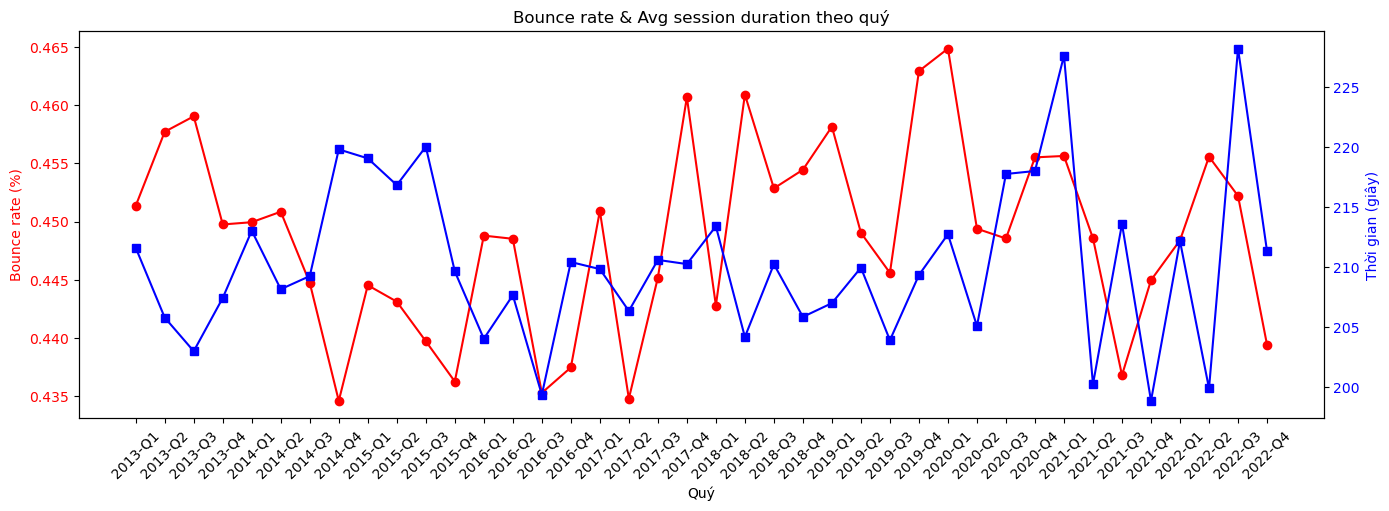

In [9]:
# --- Theo năm ---
yearly = web.groupby('year').agg(
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration=('avg_session_duration_sec', 'mean')
).reset_index()
yearly['avg_bounce_rate'] = yearly['avg_bounce_rate'] * 100  # sang %

# --- Theo quý ---
quarterly = web.groupby('year_quarter').agg(
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration=('avg_session_duration_sec', 'mean')
).reset_index()
quarterly['avg_bounce_rate'] = quarterly['avg_bounce_rate'] * 100
# sắp xếp
quarterly['sort_key'] = quarterly['year_quarter'].apply(lambda x: (int(x.split('-Q')[0]), int(x.split('-Q')[1])))
quarterly = quarterly.sort_values('sort_key').drop('sort_key', axis=1)

print("=== Theo năm ===")
print(yearly.round(2))
print("\n=== Theo quý ===")
print(quarterly.round(2))

# Vẽ biểu đồ kết hợp 2 chỉ số (dùng 2 trục y)
fig, ax1 = plt.subplots(figsize=(14,5))
ax1.plot(quarterly['year_quarter'], quarterly['avg_bounce_rate'], marker='o', color='red', label='Bounce rate (%)')
ax1.set_xlabel('Quý')
ax1.set_ylabel('Bounce rate (%)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xticklabels(quarterly['year_quarter'], rotation=45)

ax2 = ax1.twinx()
ax2.plot(quarterly['year_quarter'], quarterly['avg_session_duration'], marker='s', color='blue', label='Session duration (giây)')
ax2.set_ylabel('Thời gian (giây)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
fig.tight_layout()
plt.title('Bounce rate & Avg session duration theo quý')
plt.show()

=== Tổng page views theo traffic source (toàn bộ dữ liệu) ===
   traffic_source  page_views
2  organic_search   117606452
3     paid_search    85079551
5    social_media    68072140
1  email_campaign    55477636
4        referral    41655659
0          direct    28771362


C:\Users\NganNguyen's laptop\AppData\Local\Temp\ipykernel_7700\2181283544.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_by_source, x='page_views', y='traffic_source', palette='viridis')


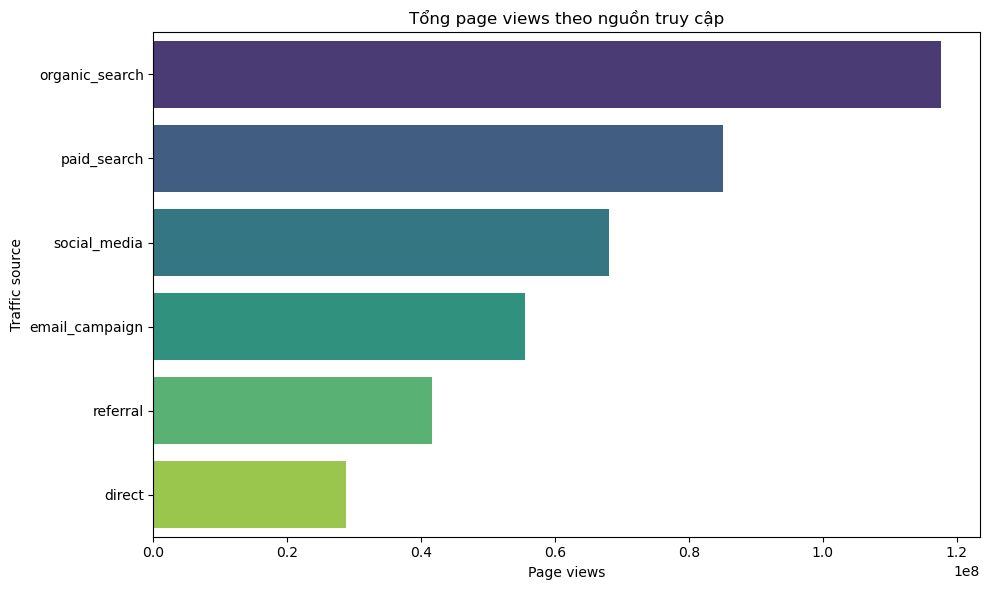

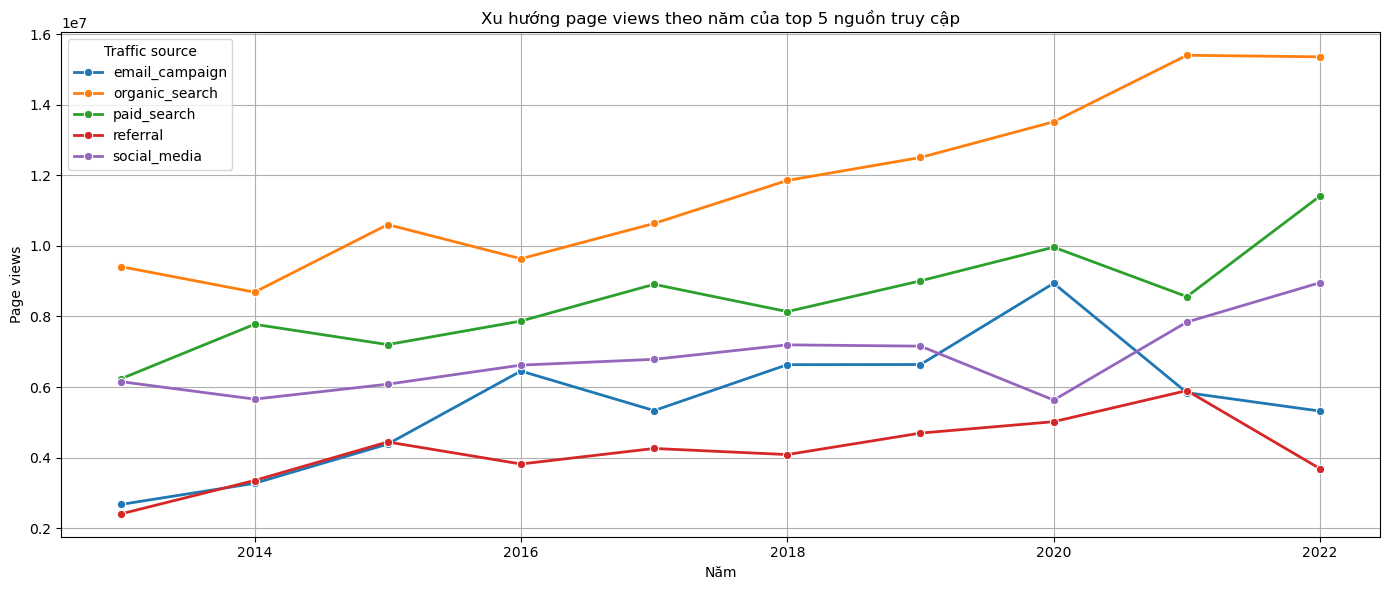

In [10]:
# 1. TỔNG PAGE VIEWS THEO TRAFFIC SOURCE (TOÀN THỜI GIAN)
# =====================================================
total_by_source = web.groupby('traffic_source')['page_views'].sum().reset_index()
total_by_source = total_by_source.sort_values('page_views', ascending=False)

print("=== Tổng page views theo traffic source (toàn bộ dữ liệu) ===")
print(total_by_source)

# Vẽ biểu đồ tròn hoặc thanh ngang
plt.figure(figsize=(10, 6))
sns.barplot(data=total_by_source, x='page_views', y='traffic_source', palette='viridis')
plt.title('Tổng page views theo nguồn truy cập')
plt.xlabel('Page views')
plt.ylabel('Traffic source')
plt.tight_layout()
plt.show()

# =====================================================
# 2. PAGE VIEWS THEO TRAFFIC SOURCE VÀ NĂM (XU HƯỚNG)
# =====================================================
yearly_source = web.groupby(['year', 'traffic_source'])['page_views'].sum().reset_index()

# Vẽ đường xu hướng cho từng nguồn (chọn top 5 nguồn có tổng page views cao nhất)
top_sources = total_by_source.head(5)['traffic_source'].tolist()
filtered = yearly_source[yearly_source['traffic_source'].isin(top_sources)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=filtered, x='year', y='page_views', hue='traffic_source', marker='o', linewidth=2)
plt.title('Xu hướng page views theo năm của top 5 nguồn truy cập')
plt.xlabel('Năm')
plt.ylabel('Page views')
plt.legend(title='Traffic source')
plt.grid(True)
plt.tight_layout()
plt.show()

# Promotion

=== Doanh thu theo năm (Promo vs Non-promo) ===
      non_promo_revenue  promo_revenue  total_revenue  pct_promo  \
year                                                               
2012       7.414977e+08            0.0   7.414977e+08        0.0   
2013       9.943656e+08    575799619.0   1.570165e+09       37.0   
2014       1.295141e+09    490201897.0   1.785343e+09       27.0   
2015       1.144072e+09    647938084.0   1.792010e+09       36.0   
2016       1.483054e+09    529309999.0   2.012364e+09       26.0   
2017       1.176418e+09    639128352.0   1.815547e+09       35.0   
2018       1.305721e+09    464002477.0   1.769723e+09       26.0   
2019       6.999746e+08    381615017.0   1.081590e+09       35.0   
2020       7.171352e+08    288973345.0   1.006109e+09       29.0   
2021       6.373847e+08    353829466.0   9.912142e+08       36.0   
2022       7.956266e+08    319680520.0   1.115307e+09       29.0   

      pct_non_promo  
year                 
2012          100.0  
2

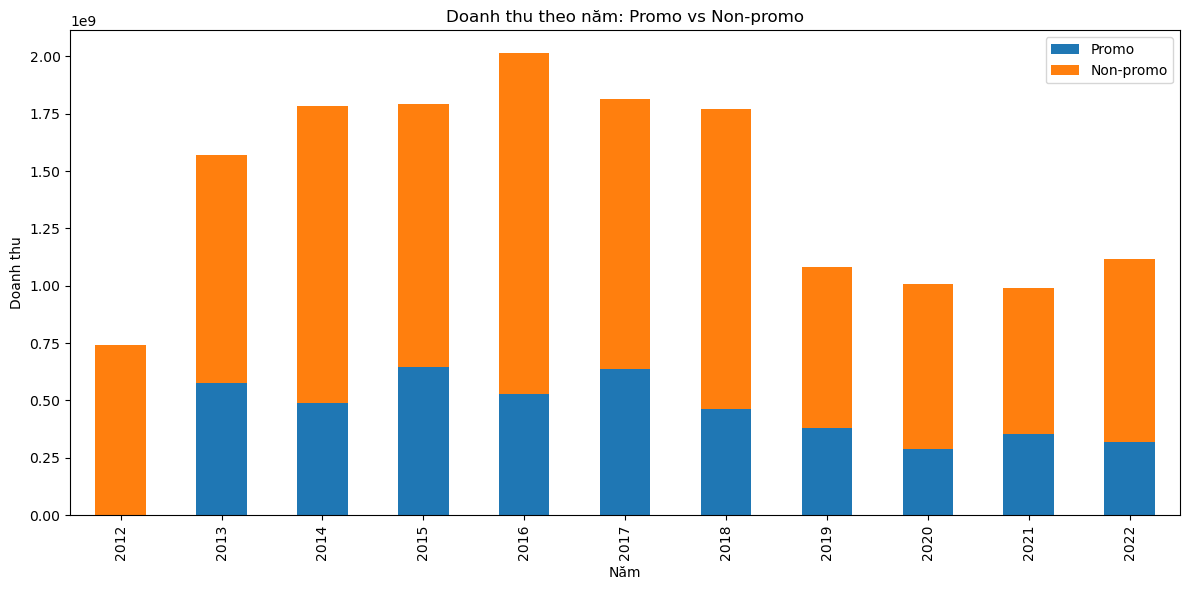


=== Số đơn hàng theo năm (Promo vs Non-promo) ===
      non_promo_orders  promo_orders  total_orders  pct_promo_orders
year                                                                
2012           32051.0           0.0       32051.0               0.0
2013           41311.0       35538.0       76849.0              46.0
2014           51135.0       29510.0       80645.0              37.0
2015           44504.0       38118.0       82622.0              46.0
2016           53880.0       28367.0       82247.0              34.0
2017           42356.0       33654.0       76010.0              44.0
2018           46360.0       23150.0       69510.0              33.0
2019           22998.0       18603.0       41601.0              45.0
2020           22167.0       12714.0       34881.0              36.0
2021           19222.0       15303.0       34525.0              44.0
2022           22719.0       13285.0       36004.0              37.0


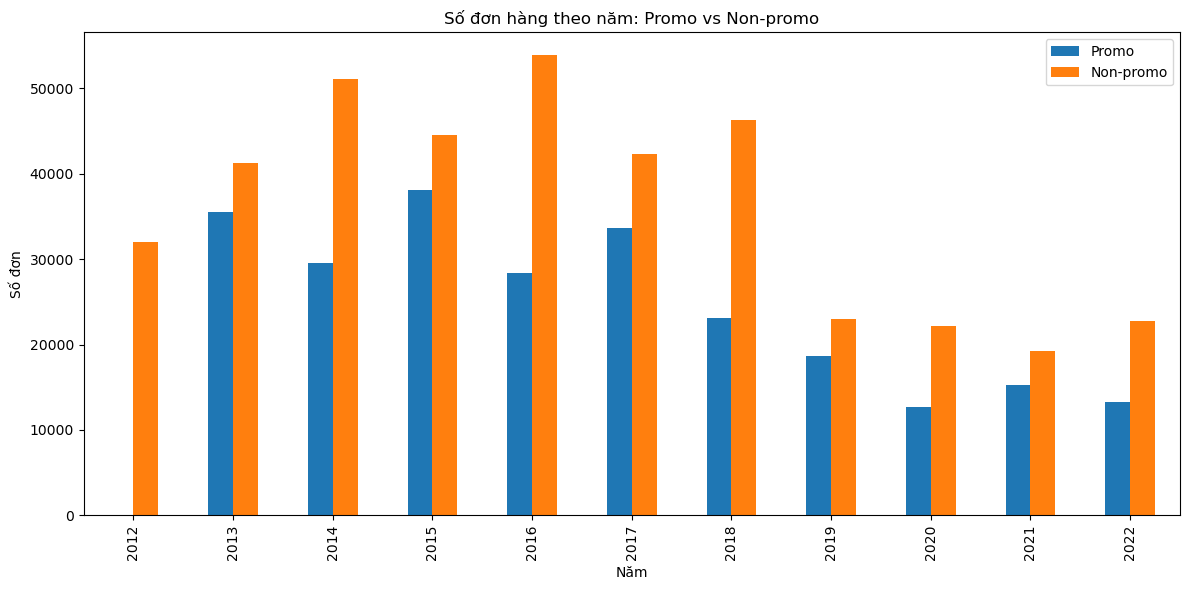

In [14]:
# Tạo line_revenue nếu chưa có
if 'line_revenue' not in order_items.columns:
    order_items['line_revenue'] = order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount']

# ===========================
# 2. XÁC ĐỊNH ORDER CÓ PROMO (tối ưu, không dùng apply)
# ===========================
# Chuẩn hóa promo_id, promo_id_2 thành string, xử lý NaN
order_items['promo_id'] = order_items['promo_id'].fillna('').astype(str)
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('').astype(str)

# Item có promo nếu promo_id hoặc promo_id_2 không rỗng và không phải 'nan' (chuỗi)
has_promo_item = (order_items['promo_id'].notna() & (order_items['promo_id'] != '') & (order_items['promo_id'] != 'nan')) | \
                 (order_items['promo_id_2'].notna() & (order_items['promo_id_2'] != '') & (order_items['promo_id_2'] != 'nan'))

# Groupby order_id: any() nhanh hơn apply rất nhiều
order_promo_flag = has_promo_item.groupby(order_items['order_id']).any().reset_index()
order_promo_flag.columns = ['order_id', 'has_promo']

# ===========================
# 3. GẮN FLAG VÀO ORDERS
# ===========================
orders_with_flag = orders.merge(order_promo_flag, on='order_id', how='left')
orders_with_flag['has_promo'] = orders_with_flag['has_promo'].fillna(False)

# ===========================
# 4. TÍNH DOANH THU THEO ORDER
# ===========================
order_revenue = order_items.groupby('order_id')['line_revenue'].sum().reset_index()
orders_with_flag = orders_with_flag.merge(order_revenue, on='order_id', how='left')
orders_with_flag['line_revenue'] = orders_with_flag['line_revenue'].fillna(0)

# ===========================
# 5. THÊM CỘT NĂM, QUÝ
# ===========================
orders_with_flag['year'] = orders_with_flag['order_date'].dt.year
orders_with_flag['quarter'] = orders_with_flag['order_date'].dt.quarter
orders_with_flag['year_quarter'] = orders_with_flag['year'].astype(str) + '-Q' + orders_with_flag['quarter'].astype(str)

# ===========================
# 6. DOANH THU THEO NĂM
# ===========================
revenue_by_year = orders_with_flag.groupby(['year', 'has_promo'])['line_revenue'].sum().reset_index()
pivot_rev = revenue_by_year.pivot(index='year', columns='has_promo', values='line_revenue').fillna(0)
pivot_rev.columns = ['non_promo_revenue', 'promo_revenue']
pivot_rev['total_revenue'] = pivot_rev['promo_revenue'] + pivot_rev['non_promo_revenue']
pivot_rev['pct_promo'] = pivot_rev['promo_revenue'] / pivot_rev['total_revenue'] * 100
pivot_rev['pct_non_promo'] = pivot_rev['non_promo_revenue'] / pivot_rev['total_revenue'] * 100

print("=== Doanh thu theo năm (Promo vs Non-promo) ===")
print(pivot_rev.round(0))

# Vẽ biểu đồ chồng
ax = pivot_rev[['promo_revenue', 'non_promo_revenue']].plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Doanh thu theo năm: Promo vs Non-promo')
plt.xlabel('Năm')
plt.ylabel('Doanh thu')
plt.legend(['Promo', 'Non-promo'])
plt.tight_layout()
plt.show()

# ===========================
# 7. SỐ ĐƠN HÀNG THEO NĂM
# ===========================
order_count_by_year = orders_with_flag.groupby(['year', 'has_promo'])['order_id'].count().reset_index()
pivot_orders = order_count_by_year.pivot(index='year', columns='has_promo', values='order_id').fillna(0)
pivot_orders.columns = ['non_promo_orders', 'promo_orders']
pivot_orders['total_orders'] = pivot_orders['promo_orders'] + pivot_orders['non_promo_orders']
pivot_orders['pct_promo_orders'] = pivot_orders['promo_orders'] / pivot_orders['total_orders'] * 100

print("\n=== Số đơn hàng theo năm (Promo vs Non-promo) ===")
print(pivot_orders.round(0))

# Vẽ biểu đồ cột nhóm
pivot_orders[['promo_orders', 'non_promo_orders']].plot(kind='bar', figsize=(12,6))
plt.title('Số đơn hàng theo năm: Promo vs Non-promo')
plt.xlabel('Năm')
plt.ylabel('Số đơn')
plt.legend(['Promo', 'Non-promo'])
plt.tight_layout()
plt.show()

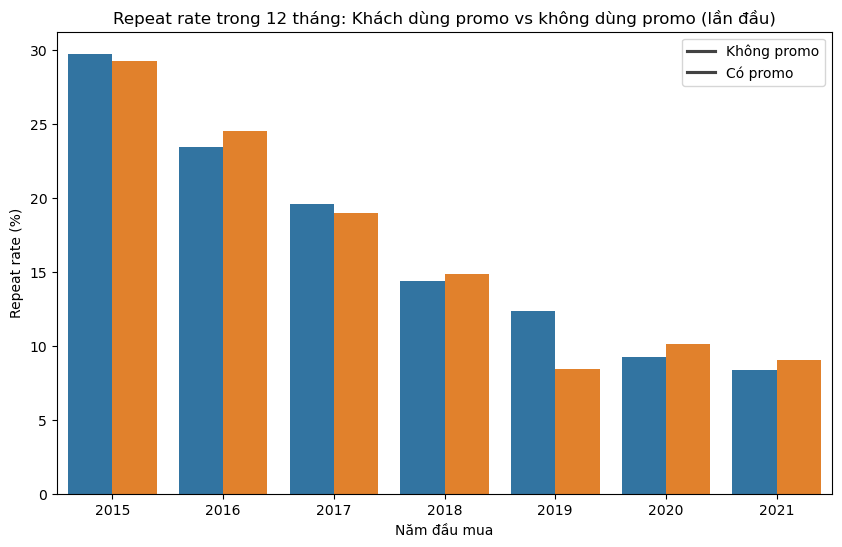

p-value cho năm 2020: 0.6615 – Có khác biệt ý nghĩa nếu p < 0.05


In [15]:
# Kiểm tra giả thuyết: Khách hàng dùng promo lần đầu có mua lại ít hơn?
# Xác định lần đầu mua của mỗi khách
first_orders = orders_with_flag.sort_values(['customer_id', 'order_date']).groupby('customer_id').first().reset_index()
first_orders = first_orders[['customer_id', 'order_date', 'has_promo']]
first_orders['first_year'] = first_orders['order_date'].dt.year

# Lấy các đơn thứ hai (trong vòng 12 tháng)
second_orders = orders_with_flag.sort_values(['customer_id', 'order_date']).groupby('customer_id').nth(1).reset_index()
second_orders = second_orders[['customer_id', 'order_date']]
second_orders.rename(columns={'order_date': 'second_order_date'}, inplace=True)

# Gộp để tính repeat trong 12 tháng
repeat_analysis = first_orders.merge(second_orders, on='customer_id', how='left')
repeat_analysis['repeat_within_12m'] = (repeat_analysis['second_order_date'] - repeat_analysis['order_date']).dt.days <= 365

# Tính tỷ lệ repeat theo nhóm promo (chỉ xét các năm gần đây, ví dụ 2015-2021)
cohort_years = [2015,2016,2017,2018,2019,2020,2021]
repeat_by_promo = repeat_analysis[repeat_analysis['first_year'].isin(cohort_years)].groupby(['first_year', 'has_promo'])['repeat_within_12m'].mean().reset_index()
repeat_by_promo['repeat_rate'] = repeat_by_promo['repeat_within_12m'] * 100

# Vẽ biểu đồ so sánh
plt.figure(figsize=(10,6))
sns.barplot(data=repeat_by_promo, x='first_year', y='repeat_rate', hue='has_promo')
plt.title('Repeat rate trong 12 tháng: Khách dùng promo vs không dùng promo (lần đầu)')
plt.xlabel('Năm đầu mua')
plt.ylabel('Repeat rate (%)')
plt.legend(['Không promo', 'Có promo'])
plt.show()

# Kiểm định thống kê (ví dụ năm 2020)
from scipy.stats import chi2_contingency
# Lập bảng ngẫu nhiên cho năm 2020
year2020 = repeat_analysis[repeat_analysis['first_year']==2020]
table = pd.crosstab(year2020['has_promo'], year2020['repeat_within_12m'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"p-value cho năm 2020: {p:.4f} – Có khác biệt ý nghĩa nếu p < 0.05")
